АНАЛИЗ РЫНОЧНОЙ КОРЗИНЫ
Количество транзакций: 7501
Количество различных товаров: 115

Частые наборы при поддержке 5%:
-----------------------------------------------------------------
{минеральная вода} -> support = 0.2384
{макароны} -> support = 0.1880
{яйца} -> support = 0.1797
{картофель-фри} -> support = 0.1709
{шоколад} -> support = 0.1638
{зеленый чай} -> support = 0.1321
{молоко} -> support = 0.1296
{говяжий фарш} -> support = 0.0983
{замороженные овощи} -> support = 0.0953
{блинчики} -> support = 0.0951
{гамбургер} -> support = 0.0872
{торт} -> support = 0.0811
{печенье} -> support = 0.0804
{эскалоп} -> support = 0.0793
{низкокалорийный йогурт} -> support = 0.0765
{рис} -> support = 0.0760
{креветки} -> support = 0.0715
{помидоры} -> support = 0.0684
{оливковое масло} -> support = 0.0659
{замороженный смузи} -> support = 0.0633
{индейка} -> support = 0.0625
{макароны, минеральная вода} -> support = 0.0612
{курица} -> support = 0.0600
{минеральная вода, шоколад} -> support = 0.

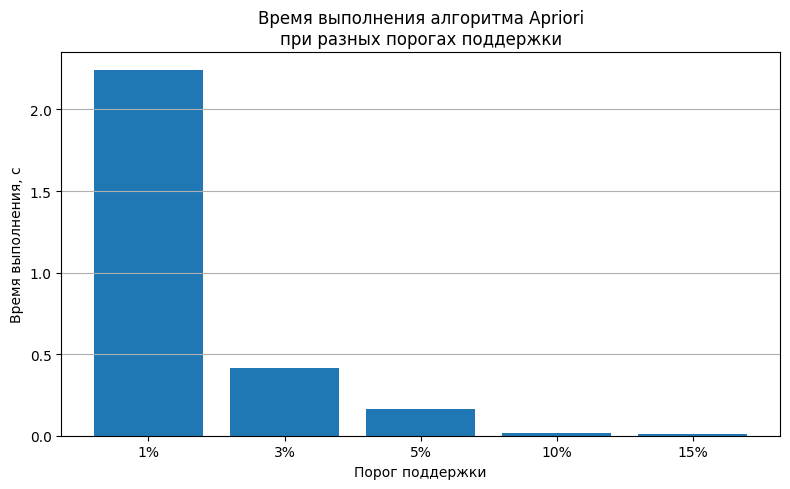

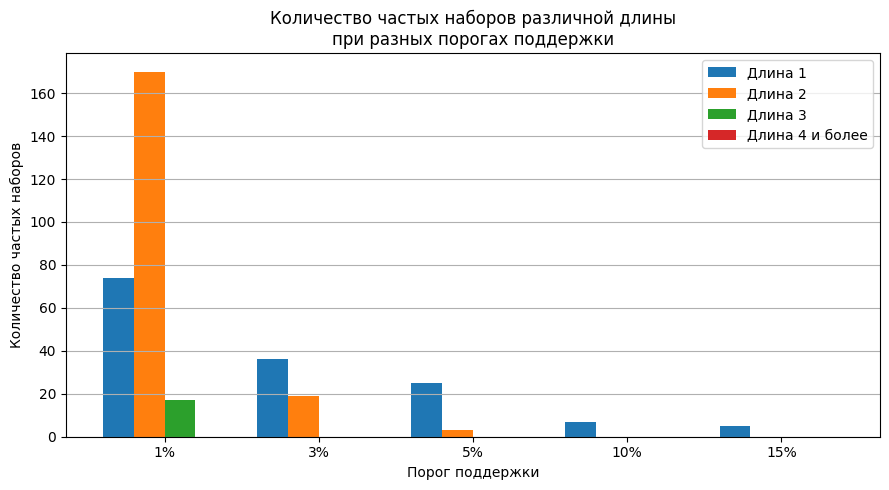

In [1]:
import csv
import itertools
import math
import time
from collections import Counter
import matplotlib.pyplot as plt


def read_data(filename):
    with open(filename, encoding="cp1251", newline="") as f:
        return [
            {x.strip() for x in row if x.strip()}
            for row in csv.reader(f)
            if any(x.strip() for x in row)
        ]


def apriori(transactions, min_support, sort_by="support"):
    n = len(transactions)
    min_count = math.ceil(n * min_support)

    counts = Counter(
        item for basket in transactions for item in basket
    )

    current = {
        frozenset([item]): count
        for item, count in counts.items()
        if count >= min_count
    }

    result = dict(current)
    k = 2

    while current:
        previous = set(current)
        candidates = set()

        for a, b in itertools.combinations(previous, 2):
            candidate = a | b

            if len(candidate) == k and all(
                frozenset(s) in previous
                for s in itertools.combinations(candidate, k - 1)
            ):
                candidates.add(candidate)

        if not candidates:
            break

        counts = Counter(
            candidate
            for basket in transactions
            for candidate in candidates
            if candidate.issubset(basket)
        )

        current = {
            candidate: count
            for candidate, count in counts.items()
            if count >= min_count
        }

        result.update(current)
        k += 1

    if sort_by == "support":
        result = sorted(
            result.items(),
            key=lambda x: (-x[1] / n, tuple(sorted(x[0])))
        )
    else:
        result = sorted(
            result.items(),
            key=lambda x: tuple(sorted(x[0]))
        )

    return [
        (tuple(sorted(items)), count / n)
        for items, count in result
    ]


def experiments(transactions):
    supports = [0.01, 0.03, 0.05, 0.10, 0.15]
    results = []

    for s in supports:
        start = time.perf_counter()
        frequent = apriori(transactions, s)
        elapsed = time.perf_counter() - start

        lengths = Counter(len(items) for items, _ in frequent)

        results.append({
            "support": s,
            "time": elapsed,
            "total": len(frequent),
            "1": lengths.get(1, 0),
            "2": lengths.get(2, 0),
            "3": lengths.get(3, 0),
            "4+": sum(
                v for k, v in lengths.items()
                if k >= 4
            )
        })

    return results


def save_results(results):
    with open(
        "experiment_results.csv",
        "w",
        encoding="utf-8-sig",
        newline=""
    ) as f:
        writer = csv.writer(f)

        writer.writerow([
            "Порог",
            "Время, с",
            "Всего наборов",
            "Длина 1",
            "Длина 2",
            "Длина 3",
            "Длина 4+"
        ])

        for r in results:
            writer.writerow([
                r["support"],
                r["time"],
                r["total"],
                r["1"],
                r["2"],
                r["3"],
                r["4+"]
            ])


def make_charts(results):
    x = [f"{r['support'] * 100:.0f}%" for r in results]

    # Диаграмма 1: время выполнения
    plt.figure(figsize=(8, 5))

    plt.bar(
        x,
        [r["time"] for r in results]
    )

    plt.xlabel("Порог поддержки")
    plt.ylabel("Время выполнения, с")
    plt.title(
        "Время выполнения алгоритма Apriori\n"
        "при разных порогах поддержки"
    )

    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig("time_vs_support.png", dpi=300)
    plt.show()

    # Диаграмма 2: количество наборов разной длины
    plt.figure(figsize=(9, 5))

    width = 0.2
    positions = list(range(len(x)))

    plt.bar(
        [p - 1.5 * width for p in positions],
        [r["1"] for r in results],
        width,
        label="Длина 1"
    )

    plt.bar(
        [p - 0.5 * width for p in positions],
        [r["2"] for r in results],
        width,
        label="Длина 2"
    )

    plt.bar(
        [p + 0.5 * width for p in positions],
        [r["3"] for r in results],
        width,
        label="Длина 3"
    )

    plt.bar(
        [p + 1.5 * width for p in positions],
        [r["4+"] for r in results],
        width,
        label="Длина 4 и более"
    )

    plt.xlabel("Порог поддержки")
    plt.ylabel("Количество частых наборов")
    plt.title(
        "Количество частых наборов различной длины\n"
        "при разных порогах поддержки"
    )

    plt.xticks(positions, x)
    plt.grid(axis="y")
    plt.legend()
    plt.tight_layout()
    plt.savefig("itemsets_by_length.png", dpi=300)
    plt.show()


def main():
    transactions = read_data("baskets.csv")

    print("=" * 65)
    print("АНАЛИЗ РЫНОЧНОЙ КОРЗИНЫ")
    print("=" * 65)

    print(f"Количество транзакций: {len(transactions)}")

    items = set()
    for basket in transactions:
        items.update(basket)

    print(f"Количество различных товаров: {len(items)}")

    # Основной запуск Apriori при поддержке 5%
    frequent = apriori(
        transactions,
        0.05,
        sort_by="support"
    )

    print()
    print("Частые наборы при поддержке 5%:")
    print("-" * 65)

    for itemset, support in frequent:
        print(
            f"{{{', '.join(itemset)}}} "
            f"-> support = {support:.4f}"
        )

    # Проверка лексикографической сортировки
    lexicographic = apriori(
        transactions,
        0.05,
        sort_by="lexicographic"
    )

    print()
    print(
        "Лексикографическая сортировка "
        f"(первые 10 из {len(lexicographic)}):"
    )

    for itemset, support in lexicographic[:10]:
        print(
            f"{{{', '.join(itemset)}}} "
            f"-> support = {support:.4f}"
        )

    # Эксперименты
    results = experiments(transactions)

    print()
    print("=" * 65)
    print("РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТОВ")
    print("=" * 65)

    print(
        f"{'Порог':<10}"
        f"{'Время, с':<15}"
        f"{'Всего':<10}"
        f"{'Длина 1':<12}"
        f"{'Длина 2':<12}"
        f"{'Длина 3':<12}"
        f"{'Длина 4+':<10}"
    )

    for r in results:
        print(
            f"{r['support'] * 100:<10.0f}"
            f"{r['time']:<15.6f}"
            f"{r['total']:<10}"
            f"{r['1']:<12}"
            f"{r['2']:<12}"
            f"{r['3']:<12}"
            f"{r['4+']:<10}"
        )

    save_results(results)
    make_charts(results)

    print()

if __name__ == "__main__":
    main()